In [1]:
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from model import ScalingLaw, GetAsymptVar, SampleAlpha
from model_general import ScalingLaw as ScalingLawGeneral
from constants import lower_bounds, test_models, delete_models, Y_names_tidy, Y_names, B, lrs, scheduler_factors, reps, n_epochs, random_seed
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from concurrent.futures import ThreadPoolExecutor, as_completed

K = 4
eps = 1e-3
Y_names = Y_names[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Data

In [2]:
# Loading
df = pd.merge(pd.read_csv('data/df_full_v1.csv').drop('Unnamed: 0', axis=1),
              pd.read_csv('data/df_full_v2.csv').drop('Unnamed: 0', axis=1), 
              on=['model', 'family', 'size', 'tokens', 'flops'], how='outer')

# Creating data objects
Y = np.array(df.loc[:,Y_names])
Y = np.clip(Y, a_min=eps, a_max=1-eps)
        
X = np.log(np.array(df.loc[:,['size','tokens']]))
X = np.hstack((X,(X[:,0]*X[:,1])[:,None]))

D = np.array(pd.get_dummies(df.family)).astype(int)
I = np.ones(shape=(D.shape[0],1))
C = np.array([lower_bounds[s] for s in Y_names]).reshape((1,-1))

Training models

In [3]:
test_models.keys()

dict_keys(['meta-llama-3', 'qwen2', 'yi-1.5', 'olmo', 'smollm', 'gemma2'])

In [4]:
reps = 2

models = {}

mu = np.mean(X, axis=0, keepdims=True)
std = np.std(X, axis=0, keepdims=True)

X_train = (X-mu)/std
Y_train = Y
D_train = D

# Model 1
models['model'] = ScalingLaw(K)
models['model'].fit(X = X_train,
                      Y = Y_train,
                      D = D_train,
                      C = C,
                      B = B,
                      lrs = lrs,
                      scheduler_factors = scheduler_factors,
                      reps = reps,
                      n_epochs = n_epochs,    
                      verbose = True,
                      device = device)

# Model 2
models['model-general'] = ScalingLawGeneral(K)
models['model-general'].fit(X_mean = X_train,
                              Y = Y_train,
                              D = D_train,
                              C = C,
                              X_phi = np.zeros(X_train.shape),
                              B = B,
                              lrs = lrs,
                              scheduler_factors = scheduler_factors,
                              reps = reps,
                              n_epochs = n_epochs,    
                              verbose = True,
                              device = device)
    
np.save(f"models/prediction_intervals/comparing_models.npy", models)

Different lrs:   0%|          | 0/3 [00:00<?, ?it/s]

Different scheduler factors:   0%|          | 0/2 [00:00<?, ?it/s]

Reps:   0%|          | 0/2 [00:00<?, ?it/s]

Training ME model:   0%|          | 0/20000 [00:00<?, ?it/s]

final grad norm: 0.005227591376751661


...

Reps:   0%|          | 0/2 [00:00<?, ?it/s]

Training ME model:   0%|          | 0/20000 [00:00<?, ?it/s]

epoch= 1000, B=10000, grad=0.12805, loss=-0.76925, lr=0.01000
 grads: {'L': 0.018390582874417305, 'lambd1': 0.12607046961784363, 'lambd2': 0.009782292880117893, 'phi_int': 0.0031452919356524944, 'phi_slope': 0.0, 'b': 0.0036180014722049236, 'beta': 0.006886010989546776}
epoch= 2000, B=10000, grad=0.10874, loss=-0.77920, lr=0.00755
 grads: {'L': 0.02114381454885006, 'lambd1': 0.10052436590194702, 'lambd2': 0.020037194713950157, 'phi_int': 0.0010704511078074574, 'phi_slope': 0.0, 'b': 0.006327486597001553, 'beta': 0.028819924220442772}
epoch= 3000, B=10000, grad=0.12491, loss=-0.77924, lr=0.00553
 grads: {'L': 0.02938123606145382, 'lambd1': 0.10130907595157623, 'lambd2': 0.04479813203215599, 'phi_int': 0.0010070401476696134, 'phi_slope': 0.0, 'b': 0.008416039869189262, 'beta': 0.04896889999508858}
epoch= 4000, B=10000, grad=0.11194, loss=-0.78006, lr=0.00401
 grads: {'L': 0.03226437047123909, 'lambd1': 0.1017153263092041, 'lambd2': 0.02025727741420269, 'phi_int': 0.0014780873898416758, '

Training ME model:   0%|          | 0/20000 [00:00<?, ?it/s]

epoch= 1000, B=10000, grad=0.07815, loss=-0.84006, lr=0.00980
 grads: {'L': 0.004328642971813679, 'lambd1': 0.07638680189847946, 'lambd2': 0.014402828179299831, 'phi_int': 0.005645169410854578, 'phi_slope': 0.0, 'b': 0.0032867006957530975, 'beta': 0.0020560522098094225}
epoch= 2000, B=10000, grad=0.07125, loss=-0.84866, lr=0.00747
 grads: {'L': 0.013306067325174809, 'lambd1': 0.06565766036510468, 'lambd2': 0.022869287058711052, 'phi_int': 0.0012223694939166307, 'phi_slope': 0.0, 'b': 0.005991058889776468, 'beta': 0.00529597420245409}
epoch= 3000, B=10000, grad=0.08202, loss=-0.85071, lr=0.00542
 grads: {'L': 0.018985319882631302, 'lambd1': 0.07433488219976425, 'lambd2': 0.02472493052482605, 'phi_int': 0.000905524764675647, 'phi_slope': 0.0, 'b': 0.00990352500230074, 'beta': 0.011442208662629128}
epoch= 4000, B=10000, grad=0.08326, loss=-0.85093, lr=0.00393
 grads: {'L': 0.012175225652754307, 'lambd1': 0.0794757604598999, 'lambd2': 0.01860133744776249, 'phi_int': 0.001037607085891068, '

Results (checking if the fit is the same or close enough)

In [6]:
models = np.load("models/prediction_intervals/comparing_models.npy", allow_pickle=True).item()

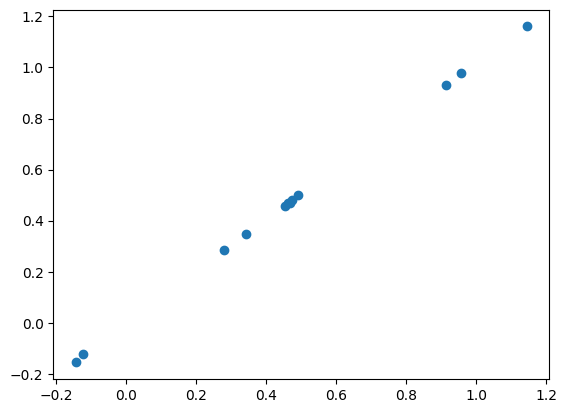

In [15]:
plt.scatter(models['model'].beta.reshape(-1),models['model-general'].beta.reshape(-1))
plt.show()

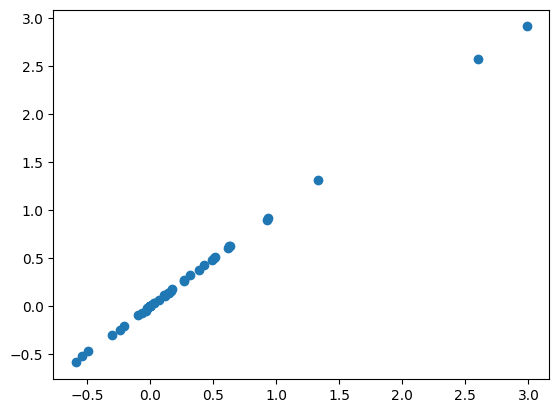

In [16]:
plt.scatter(models['model'].lambd.reshape(-1),models['model-general'].lambd.reshape(-1))
plt.show()

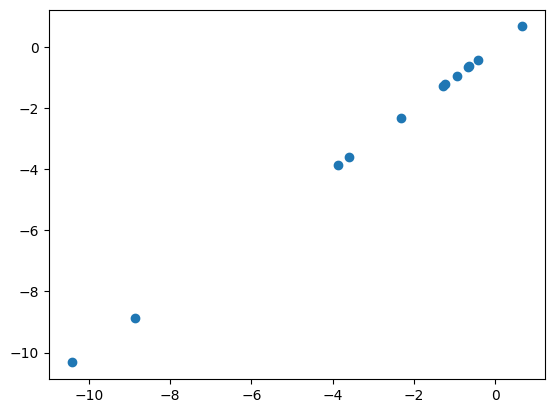

In [17]:
plt.scatter(models['model'].b.reshape(-1),models['model-general'].b.reshape(-1))
plt.show()

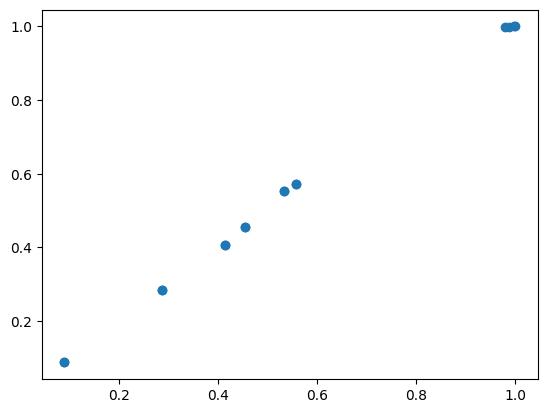

In [18]:
plt.scatter(models['model'].sigma.reshape(-1),models['model-general'].sigma.reshape(-1))
plt.show()

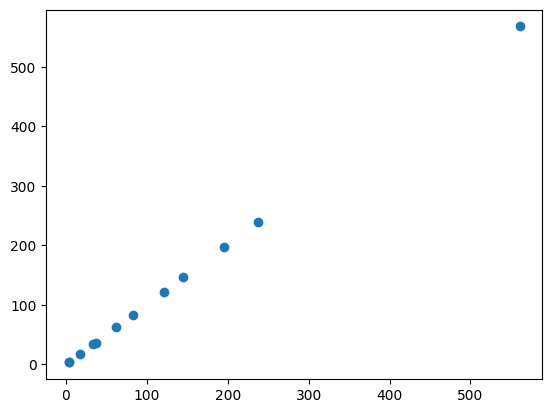

In [21]:
plt.scatter(models['model'].phi.reshape(-1),np.exp(models['model-general'].phi_int.reshape(-1)))
plt.show()